In [1]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

import sys
my_path = "../../../QHamSolver/Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from fit_funcs import *
import costfun.costfun as cost
import utils.figures as fig_help
from RandomMatrixTheory import goe, gue
from tools import *
import entropy as ent

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)


import itertools
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{physics}\usepackage{xcolor}\usepackage{amsmath}\usepackage{amsfonts}'


%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import gamma as Gamma
from scipy.special import lambertw
from scipy.special import dawsn as dawson
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
 
# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists


def base_dir(BC = 0):
    """
    Base directory for input model for d-dimension
    """
    dirx = f"../results/" + (f"PBC/" if BC else f"OBC/")
    return dirx

%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}

/Users/rafal.swietek/Projects/CODES/LGT_Project/2DFermiHubbard/Jupyter_Notebook
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../../QHamSolver/Python/


../results/OBC/MonomerDensity/_Lx=4,Ly=4,Nu=2,Nd=2,J=1,U=4,delta=2,F=0.1.hdf5
../results/OBC/MonomerDensity/_Lx=4,Ly=4,Nu=2,Nd=2,J=1,U=4,delta=2,F=0.2.hdf5
../results/OBC/MonomerDensity/_Lx=4,Ly=4,Nu=2,Nd=2,J=1,U=4,delta=2,F=0.3.hdf5
../results/OBC/MonomerDensity/_Lx=4,Ly=4,Nu=2,Nd=2,J=1,U=4,delta=2,F=0.4.hdf5
../results/OBC/MonomerDensity/_Lx=4,Ly=4,Nu=2,Nd=2,J=1,U=4,delta=2,F=0.5.hdf5
../results/OBC/MonomerDensity/_Lx=4,Ly=4,Nu=2,Nd=2,J=1,U=4,delta=2,F=0.6.hdf5
../results/OBC/MonomerDensity/_Lx=4,Ly=4,Nu=2,Nd=2,J=1,U=4,delta=2,F=0.7.hdf5
../results/OBC/MonomerDensity/_Lx=4,Ly=4,Nu=2,Nd=2,J=1,U=4,delta=2,F=0.8.hdf5
../results/OBC/MonomerDensity/_Lx=4,Ly=4,Nu=2,Nd=2,J=1,U=4,delta=2,F=0.9.hdf5
../results/OBC/MonomerDensity/_Lx=4,Ly=4,Nu=2,Nd=2,J=1,U=4,delta=2,F=1.hdf5
../results/OBC/MonomerDensity/_Lx=4,Ly=4,Nu=2,Nd=2,J=1,U=4,delta=2,F=1.1.hdf5
../results/OBC/MonomerDensity/_Lx=4,Ly=4,Nu=2,Nd=2,J=1,U=4,delta=2,F=1.2.hdf5
../results/OBC/MonomerDensity/_Lx=4,Ly=4,Nu=2,Nd=2,J=1,U=4,delta=2

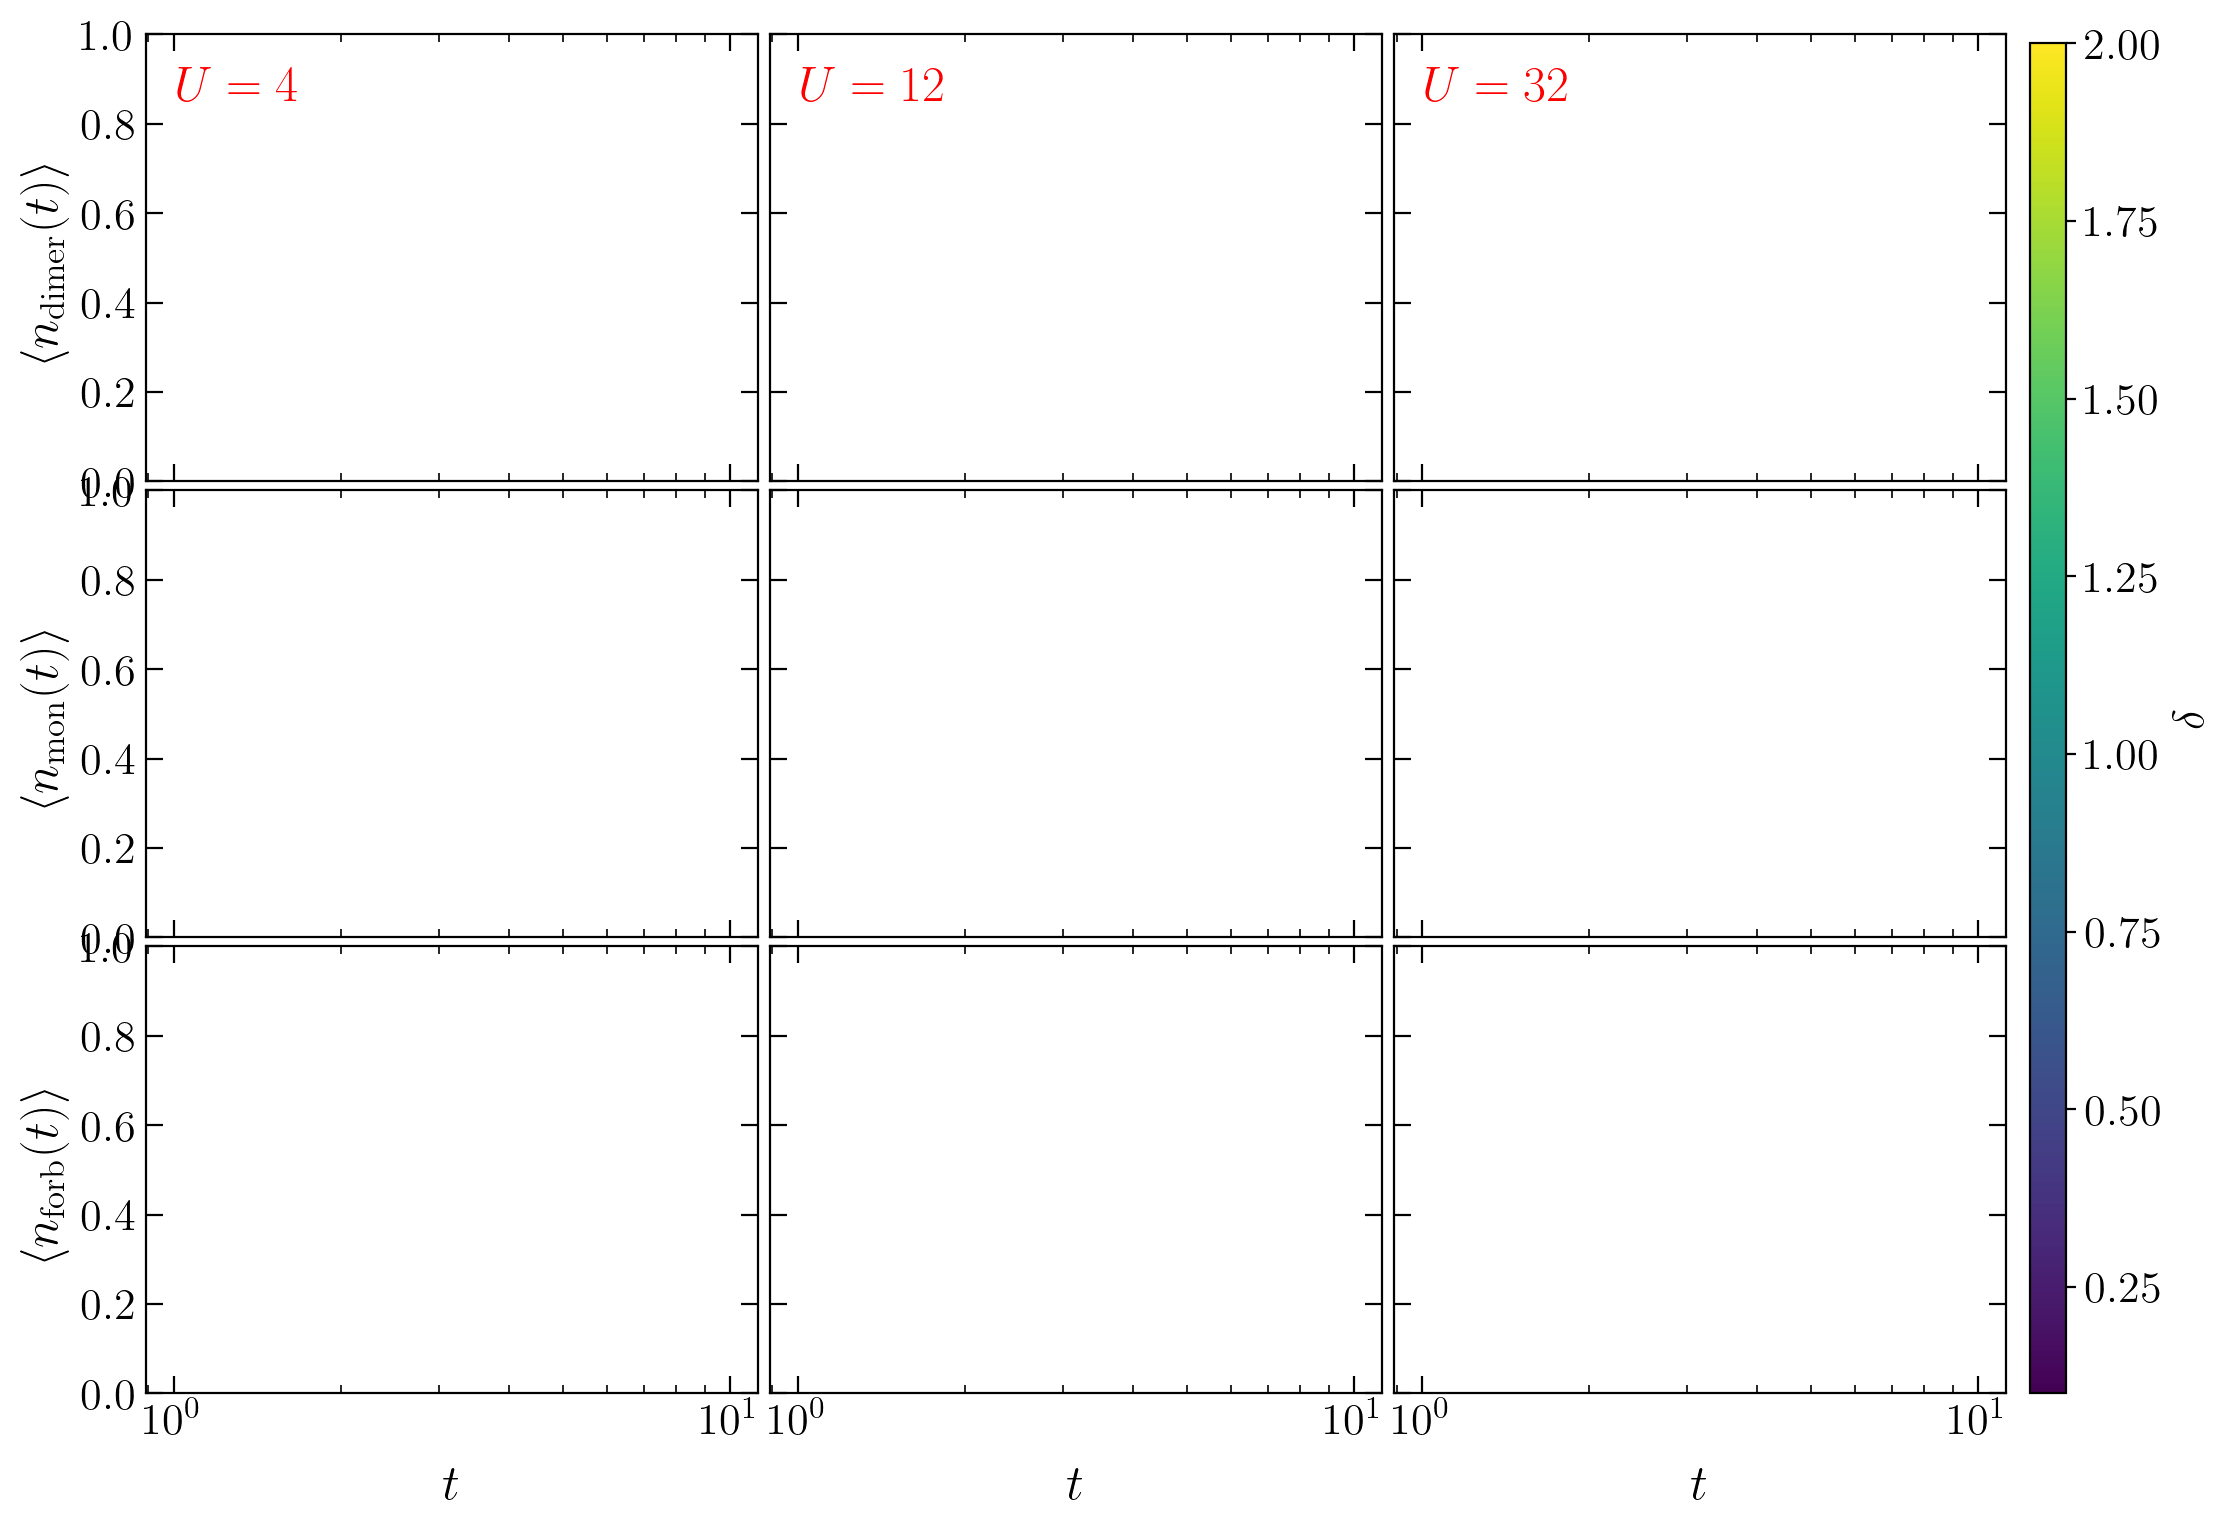

In [62]:
Lx = 4
Ly = 4
Nu = 2
Nd = 2
J = 1
U = 24
delta = 12
BC = 0 #PBC: BC=1

Flist = np.arange(0.1, 2.01, 0.1)
norm = matplotlib.colors.Normalize(
                vmin=min(Flist),
                vmax=max(Flist) )

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

fig, axis = plt.subplots( nrows=3, ncols=3, figsize=(12,9), dpi = 200, sharex=True, sharey='row')
# fig2, axis2 = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True)#, sharey='row')

for iiU, U in enumerate( [4, 12, 32] ):
    delta = U/2
    dimer = np.zeros(Flist.shape)
    density = np.zeros(Flist.shape)
    for iiF, Fx in enumerate(Flist):
        col = s_m.to_rgba(Fx)
        
        # name = base_dir(BC) + "GaugeViolation/" + info(Lx, Ly, Nu, Nd, J, U, delta, Fx)
        name = base_dir(BC) + "MonomerDensity/" + info(Lx, Ly, Nu, Nd, J, U, delta, Fx)
        if exists(name):
            with h5py.File(name, "r") as file:
                try:
                    times = np.array(file.get('times'))[0][1:]
                    density_dimer = np.array(file.get('density_dimer'))[0][1:]
                    density_monomer = np.array(file.get('density_monomer'))[0][1:]
                    density_forbidden = np.array(file.get('density_forbidden'))[0][1:]
                    
                    axis[0, iiU].plot(times, density_dimer, color = col, marker='o', markersize=1, lw=0.7)
                    axis[1, iiU].plot(times, density_monomer, color = col, marker='o', markersize=1, lw=0.7)
                    axis[2, iiU].plot(times, density_forbidden, color = col, marker='o', markersize=1, lw=0.7)
                    
                    dimer[iiF] = np.mean(density_dimer[-200:])
                    density[iiF] = np.mean(density_forbidden[-200:])
                except IndexError:
                    print(name)
        else:
            print(name)
    # axis2.scatter(Flist, dimer, marker='o', color='red' if iiU else 'k', label = r"$\langle n_{\rm dimer}(\infty)\rangle$")
    # axis2.scatter(Flist, density, marker='s', color='red' if iiU else 'k', facecolor='None', label = r"$\langle n_{\rm forb}(\infty)\rangle$")

    xscal = 'log'
    yscal = 'linear'
    
    fig_help.set_plot_elements(axis[0, iiU], ylabel=r"$\langle n_{\rm dimer}(t)\rangle$" if iiU==0 else "", xlabel=r"", font_size=16, set_legend=0, xscale=xscal, yscale=yscal)
    fig_help.set_plot_elements(axis[1, iiU], ylabel=r"$\langle n_{\rm mon}(t)\rangle$" if iiU==0 else "", xlabel=r"", font_size=16, set_legend=0, xscale=xscal, yscale=yscal)
    fig_help.set_plot_elements(axis[2, iiU], ylabel=r"$\langle n_{\rm forb}(t)\rangle$" if iiU==0 else "", xlabel=r"$t$", font_size=16, set_legend=0, xscale=xscal, yscale=yscal)

    # x = np.linspace(min(times), 0.15, 1000)
    # # axis[0, iiU].plot(x, 15*x**2, color = 'k', ls='--')
    # axis[1, iiU].plot(x, 72*x**4, color = 'red', ls='-.')
    # # axis[0, iiU].annotate(r"$\sim t^2$", fontsize=16, xy=(0.08, 0.55), xycoords='axes fraction', color='k')
    axis[0, iiU].annotate(r"$U=%g$"%U, fontsize=18, xy=(0.05, 0.85), xycoords='axes fraction', color='red')

fig.subplots_adjust(wspace = 0.02, hspace=0.02)
cbar_ax = fig.add_axes([0.91, 0.125, 0.015, 0.75])
cbar    = fig.colorbar(s_m, cax=cbar_ax, orientation='vertical')#, extend='max')
cbar.set_label(r"$\delta$", fontsize=16)
cbar.ax.tick_params(labelsize=16)
# cbar_ax.yaxis.set_label_coords(1.6, 0.99)
# fig_help.set_plot_elements(axis2, ylabel=r"gauge $t\to\infty$, $\langle n_{\rm forb}(\infty)\rangle$", xlabel=r"$F$", font_size=16, set_legend=0, xscale='linear', yscale='linear')       

NameError: name 'density_dimer' is not defined

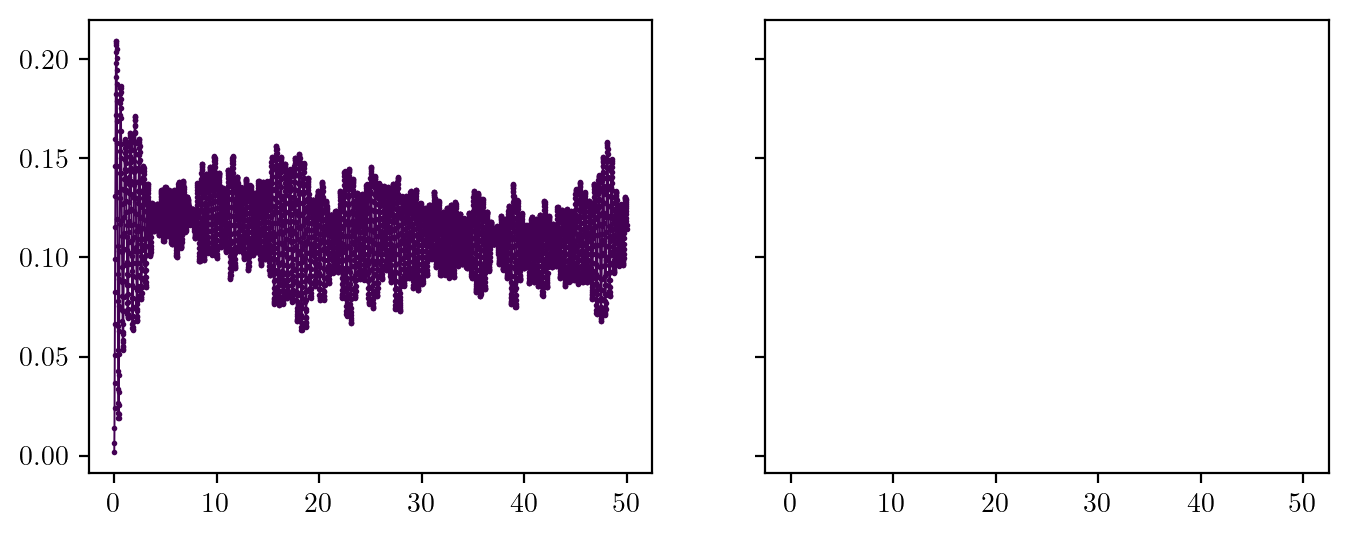

In [28]:
Lx = 4
Ly = 4
Nu = 2
Nd = 2
J = 1
U = 24
delta = 12
BC = 1 #PBC: BC=1

Flist = np.arange(0.0, 1.01, 0.2)
norm = matplotlib.colors.Normalize(
                vmin=min(Flist),
                vmax=max(Flist) )

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(8,3), dpi = 200, sharex=True, sharey='row')
# fig2, axis2 = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True)#, sharey='row')

for iiU, U in enumerate( [24, 36] ):
    delta = U/2
    dimer = np.zeros(Flist.shape)
    density = np.zeros(Flist.shape)
    for iiF, Fx in enumerate(Flist):
        col = s_m.to_rgba(Fx)
        
        name = base_dir(BC) + "GaugeViolation/" + info(Lx, Ly, Nu, Nd, J, U, delta, Fx)
        # name = base_dir(BC) + "MonomerDensity/" + info(Lx, Ly, Nu, Nd, J, U, delta, Fx)
        if exists(name):
            with h5py.File(name, "r") as file:
                try:
                    times = np.array(file.get('times'))[0][1:]
                    gauge = np.array(file.get('gauge_violation'))[0][1:]
                    
                    axis[iiU].plot(times, gauge, color = col, marker='o', markersize=1, lw=0.7)
                    
                    dimer[iiF] = np.mean(density_dimer[-200:])
                    density[iiF] = np.mean(density_forbidden[-200:])
                except IndexError:
                    print(name)
        else:
            print(name)
    # axis2.scatter(Flist, dimer, marker='o', color='red' if iiU else 'k', label = r"$\langle n_{\rm dimer}(\infty)\rangle$")
    # axis2.scatter(Flist, density, marker='s', color='red' if iiU else 'k', facecolor='None', label = r"$\langle n_{\rm forb}(\infty)\rangle$")

    xscal = 'log'
    yscal = 'linear'
    
    fig_help.set_plot_elements(axis[iiU], ylabel=r"$\mathcal{G}(t)$" if iiU == 0 else "", xlabel=r"$t$", font_size=16, set_legend=0, xscale=xscal, yscale=yscal)

    axis[iiU].annotate(r"$U=%g$"%U, fontsize=18, xy=(0.05, 0.85), xycoords='axes fraction', color='red')

fig.subplots_adjust(wspace = 0.02, hspace=0.02)
cbar_ax = fig.add_axes([0.91, 0.125, 0.015, 0.75])
cbar    = fig.colorbar(s_m, cax=cbar_ax, orientation='vertical')#, extend='max')
cbar.set_label(r"$\delta$", fontsize=16)
cbar.ax.tick_params(labelsize=16)
# cbar_ax.yaxis.set_label_coords(1.6, 0.99)
# fig_help.set_plot_elements(axis2, ylabel=r"gauge $t\to\infty$, $\langle n_{\rm forb}(\infty)\rangle$", xlabel=r"$F$", font_size=16, set_legend=0, xscale='linear', yscale='linear')       

In [32]:
for Lx in [2, 4, 6]:
    for Ly in [2, 4, 6]:
        # dim = binom(2*Lx*Ly, Lx*Ly/4)
        dim = 6**(Lx * Ly) / Lx / Ly / 64
        print(Lx, Ly, dim)

2 2 5.0625
2 4 3280.5
2 6 2834352.0
4 2 3280.5
4 4 2754990144.0
4 6 3084883683803136.0
6 2 2834352.0
6 4 3084883683803136.0
6 6 4.47674687434485e+24


## LATTICE SKETCHES

In [ ]:
def add_curved_double_arrow(axis, x1, y1, x2, y2, color='blue', lw=1.5, rad=0.3, alpha=0.7):
    """
    Add a curved double-headed arrow from (x1, y1) to (x2, y2) on the given axis.

    Parameters:
    - axis: matplotlib axis object
    - x1, y1: starting point (particle position)
    - x2, y2: ending point (neighboring empty site)
    - color: color of the arrow
    - lw: line width
    - rad: curvature radius (0.3 is moderate; increase for more curve)
    - alpha: transparency
    """
    arrow = FancyArrowPatch(
        (x1, y1), (x2, y2),
        connectionstyle=f"arc3,rad={rad}",
        arrowstyle='<->',  # Double-headed arrow
        color=color,
        lw=lw,
        alpha=alpha,
        mutation_scale=12  # Controls size of arrowheads
    )
    axis.add_patch(arrow)
    
def add_curved_double_arrow_simple(axis, x1, y1, x2, y2, color='blue', lw=1.5, rad=0.3):
    axis.annotate(
        '',
        xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle='<->',
            color=color,
            lw=lw,
            connectionstyle=f'arc3,rad={rad}'
        ),
        annotation_clip=False
    )

### BOSONIC

-0.7999999999999998
0.0
0.8000000000000003
1.6
0.8000000000000003
-1.2
-0.7999999999999998
-1.6
1.6
0.0


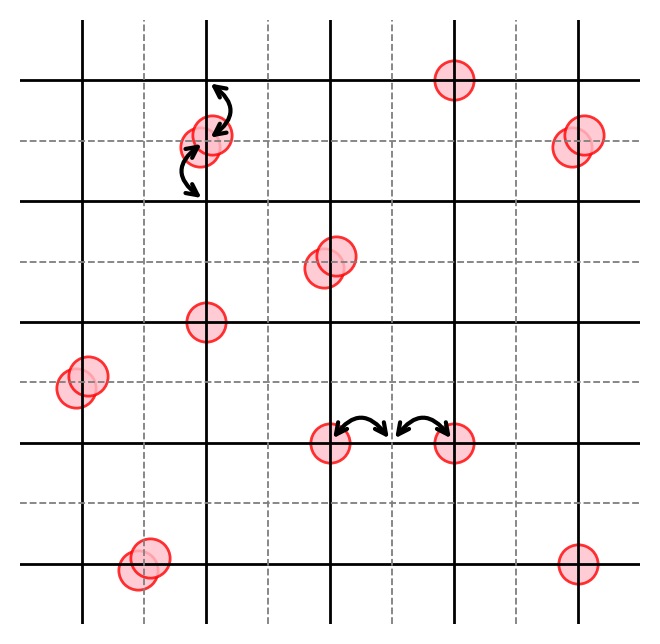

In [4]:

xmin = -2
xmax = 2

ymin = -2
ymax = 2

f0 = 5
omega0 = 2
gamma = 0.1

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,4), dpi = 200)

axis.tick_params(axis='y', which='both', bottom=False, top=False, labelbottom=False, labeltop=0)
axis.set_yticks([])
axis.set_yticklabels([])
axis.tick_params(axis='x', which='both', bottom=0, top=False, labelbottom=0)

axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
axis.spines['bottom'].set_visible(False)
axis.spines['left'].set_visible(False)

# axis.arrow(xmin, 0, xmax - xmin, 0, head_width=0.25, head_length=0.25, length_includes_head=True, color='k', lw=2)
# axis.arrow(0, ymin, 0, ymax - ymin, head_width=0.25, head_length=0.25, length_includes_head=True, color='k', lw=2)

axis.set_xlim(xmin, xmax)
axis.set_ylim(ymin, ymax)

L = 10
dx = 2*(xmax - xmin) / L
for x in np.arange(xmin + dx/2, xmax+0.1, dx):
    axis.axvline(x=x, ls='-', color='k', lw=1)
    axis.axhline(y=x, ls='-', color='k', lw=1)
    
for x in np.arange(xmin + dx, xmax+0., dx):
    axis.axvline(x=x, ls='--', color='gray', lw=0.66)
    axis.axhline(y=x, ls='--', color='gray', lw=0.66)

N = L**2 / 2

positions = [
    [3,5],[5,3], [7, 3], [9,1], [7,9]
]
for [x,y] in positions:
    print(xmin + x*dx/2)
    axis.scatter(xmin + x*dx/2, ymin + y*dx/2, marker='o', color='red', s=200, edgecolor='red', facecolor='pink', alpha=0.8)

positions = [
    [2,1],[3,8], [1,4], [9,8], [5,6] 
]
for [x,y] in positions:
    print(xmin + x*dx/2)
    axis.scatter(xmin + x*dx/2 - dx/20, ymin + y*dx/2 - dx/20, marker='o', color='red', s=200, edgecolor='red', facecolor='pink', alpha=0.8)
    axis.scatter(xmin + x*dx/2 + dx/20, ymin + y*dx/2 + dx/20, marker='o', color='red', s=200, edgecolor='red', facecolor='pink', alpha=0.8)
# Helper: convert grid indices to physical coordinates
def grid_to_coord(x_grid, y_grid):
    return xmin + x_grid * dx / 2, ymin + y_grid * dx / 2

# Add curved double-headed arrows from particles to neighboring empty sites
[x, y] = [6, 3]
x_coord, y_coord = grid_to_coord(x, y)
nx, ny = x+1, y
nx_coord, ny_coord = grid_to_coord(nx, ny)
add_curved_double_arrow_simple(axis, x_coord, y_coord, nx_coord, ny_coord, color='k', lw=1.5, rad=-0.75)
nx, ny = x-1, y
nx_coord, ny_coord = grid_to_coord(nx, ny)
add_curved_double_arrow_simple(axis, x_coord, y_coord, nx_coord, ny_coord, color='k', lw=1.5, rad=0.75)

[x, y] = [3, 8]
x_coord, y_coord = grid_to_coord(x, y)
nx, ny = x, y+1
nx_coord, ny_coord = grid_to_coord(nx, ny)
add_curved_double_arrow_simple(axis, x_coord, y_coord, nx_coord, ny_coord, color='k', lw=1.5, rad=0.75)
nx, ny = x, y-1
nx_coord, ny_coord = grid_to_coord(nx, ny)
add_curved_double_arrow_simple(axis, x_coord, y_coord, nx_coord, ny_coord, color='k', lw=1.5, rad=0.75)


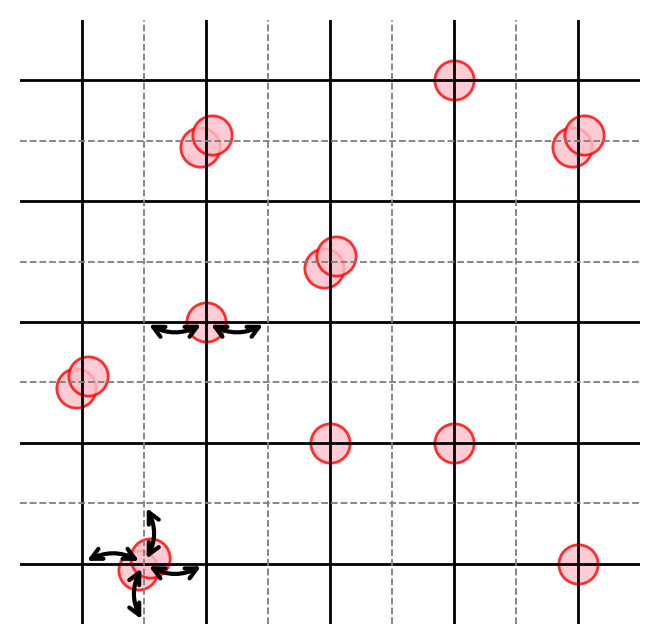

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# Parameters
xmin = -2
xmax = 2
ymin = -2
ymax = 2
f0 = 5
omega0 = 2
gamma = 0.1

fig, axis = plt.subplots(nrows=1, ncols=1, figsize=(4, 4), dpi=200)

# Remove ticks and spines
axis.tick_params(axis='y', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axis.set_yticks([])
axis.set_yticklabels([])
axis.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
axis.spines['bottom'].set_visible(False)
axis.spines['left'].set_visible(False)

axis.set_xlim(xmin, xmax)
axis.set_ylim(ymin, ymax)

# Grid setup
L = 10
dx = 2 * (xmax - xmin) / L

# Draw grid lines
for x in np.arange(xmin + dx/2, xmax + 0.1, dx):
    axis.axvline(x=x, ls='-', color='k', lw=1)
    axis.axhline(y=x, ls='-', color='k', lw=1)

for x in np.arange(xmin + dx, xmax + 0., dx):
    axis.axvline(x=x, ls='--', color='gray', lw=0.66)
    axis.axhline(y=x, ls='--', color='gray', lw=0.66)

# Define particle positions (in grid indices)
# First set: "particles" (solid red circles)
positions_particles = [
    [3, 5], [5, 3], [7, 3], [9, 1], [7, 9]
]

# Second set: "particles" (double circles, offset slightly)
positions_double = [
    [2, 1], [3, 8], [1, 4], [9, 8], [5, 6]
]

# Convert grid indices to physical coordinates
def grid_to_coord(x_grid, y_grid):
    return xmin + x_grid * dx / 2, ymin + y_grid * dx / 2

# Plot particles
for x, y in positions_particles:
    x_coord, y_coord = grid_to_coord(x, y)
    axis.scatter(x_coord, y_coord, marker='o', color='red', s=200, edgecolor='red', facecolor='pink', alpha=0.8)

for x, y in positions_double:
    x_coord, y_coord = grid_to_coord(x, y)
    axis.scatter(x_coord - dx/20, y_coord - dx/20, marker='o', color='red', s=200, edgecolor='red', facecolor='pink', alpha=0.8)
    axis.scatter(x_coord + dx/20, y_coord + dx/20, marker='o', color='red', s=200, edgecolor='red', facecolor='pink', alpha=0.8)

# Define all occupied sites (for checking neighbors)
occupied = set()
for x, y in positions_particles:
    occupied.add((x, y))
for x, y in positions_double:
    occupied.add((x, y))
# Define all occupied sites (for checking neighbors)
occupied = set()
for x, y in positions_particles:
    occupied.add((x, y))
for x, y in positions_double:
    occupied.add((x, y))

# Define neighbor directions (4-connected: up, down, left, right)
neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]

# Helper: convert grid indices to physical coordinates
def grid_to_coord(x_grid, y_grid):
    return xmin + x_grid * dx / 2, ymin + y_grid * dx / 2

# Add curved double-headed arrows from particles to neighboring empty sites
[x, y] = positions_particles[0]
x_coord, y_coord = grid_to_coord(x, y)
nx, ny = x+1, y
nx_coord, ny_coord = grid_to_coord(nx, ny)
add_curved_double_arrow_simple(axis, x_coord, y_coord, nx_coord, ny_coord, color='k', lw=1.5, rad=0.3)
nx, ny = x-1, y
nx_coord, ny_coord = grid_to_coord(nx, ny)
add_curved_double_arrow_simple(axis, x_coord, y_coord, nx_coord, ny_coord, color='k', lw=1.5, rad=-0.3)

[x, y] = positions_double[0]
x_coord, y_coord = grid_to_coord(x, y)
for dx_n, dy_n in neighbors:
    nx, ny = x + dx_n, y + dy_n
    if (nx, ny) not in occupied and 0 <= nx < L and 0 <= ny < L:
        nx_coord, ny_coord = grid_to_coord(nx, ny)
        add_curved_double_arrow_simple(axis, x_coord, y_coord, nx_coord, ny_coord, color='k', lw=1.5, rad=0.3)

3.2082593202564595
5.588200109794961
8.101474232666796


Text(16.878759594743862, 1.17, '$J$')

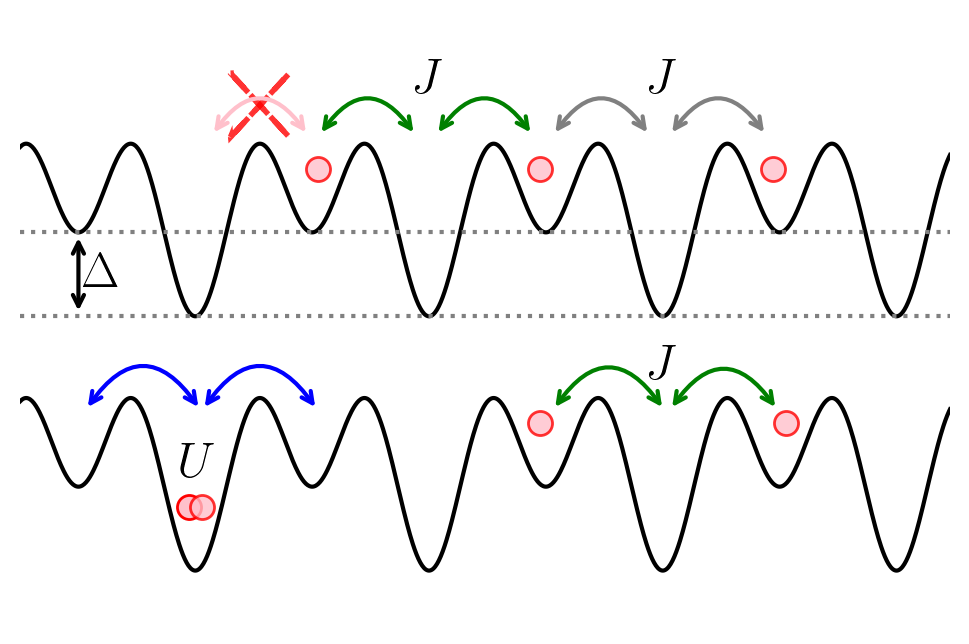

In [8]:

xmin = 0
xmax = 25

ymin = -0.75
ymax = 4

f0 = 5
omega0 = 2
gamma = 0.1

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(6,4), dpi = 200)

axis.tick_params(axis='y', which='both', bottom=False, top=False, labelbottom=False, labeltop=0)
axis.set_yticks([])
axis.set_yticklabels([])
axis.tick_params(axis='x', which='both', bottom=0, top=False, labelbottom=0)

axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
axis.spines['bottom'].set_visible(False)
axis.spines['left'].set_visible(False)

# axis.arrow(xmin, 0, xmax - xmin, 0, head_width=0.25, head_length=0.25, length_includes_head=True, color='k', lw=2)
# axis.arrow(0, ymin, 0, ymax - ymin, head_width=0.25, head_length=0.25, length_includes_head=True, color='k', lw=2)

axis.set_xlim(xmin, xmax)
axis.set_ylim(ymin, ymax)

x = np.linspace(0, 25, 1000)
# axis.plot(x, np.sin(x))

def superpotential(x):
    return np.sin(x+np.pi/2)**2 + 0.33*np.sin(x)
axis.plot(x, superpotential(x), color='k')

axis.plot(x, 2+superpotential(x), color='k')

# axis.plot(x, 4+superpotential(x), color='k')

x2 = np.pi*3/2
y2 = superpotential(x2)
x = x2 - 1 / 6
y = y2 + 0.5
axis.scatter(x, y, marker='o', color='red', s=75, edgecolor='red', facecolor='pink')
# axis.arrow(x, y - 0.25, 0, 0.5, color='red', alpha=0.8, head_width=0.2, head_length=0.15, length_includes_head=True, lw=1)

x = x2 + 1 / 6
y = y2 + 0.5
axis.scatter(x, y, marker='o', color='red', s=75, edgecolor='red', facecolor='pink', alpha=0.8)
# axis.arrow(x, y + 0.25, 0, -0.5, color='red', alpha=0.8, head_width=0.2, head_length=0.15, length_includes_head=True, lw=1)

add_curved_double_arrow_simple(axis, x, y+0.75, x + np.pi, y+0.75, color='blue', lw=1.5, rad=-0.75)
add_curved_double_arrow_simple(axis, x, y+0.75, x - np.pi, y+0.75, color='blue', lw=1.5, rad=0.75)
add_curved_double_arrow_simple(axis, x + 0.0 + 3*np.pi, y+0.75, x + 4*np.pi - 0.1, y+0.75, color='green', lw=1.5, rad=-0.75)
add_curved_double_arrow_simple(axis, x + 0.0 + 4*np.pi, y+0.75, x + 5*np.pi - 0.2, y+0.75, color='green', lw=1.5, rad=-0.75)

x2 = np.pi*1/2
y2 = 2+superpotential(x2)
x = x2 - 1 / 6
y = y2 + 0.5
# axis.scatter(x, y, marker='o', color='red', s=75, edgecolor='red', facecolor='pink', alpha=0.8)
# axis.arrow(x, y - 0.25, 0, 0.5, color='red', alpha=0.8, head_width=0.2, head_length=0.15, length_includes_head=True, lw=1)

x2 = np.pi*5/2
y2 = 2+superpotential(x2)
x = x2 + 1 / 6
y = y2 + 0.5
axis.scatter(x, y, marker='o', color='red', s=75, edgecolor='red', facecolor='pink', alpha=0.8)
# axis.arrow(x, y + 0.25, 0, -0.5, color='red', alpha=0.8, head_width=0.2, head_length=0.15, length_includes_head=True, lw=1)

# add_curved_double_arrow_simple(axis, x - 2*np.pi, y+0.25, x - np.pi - 0.5, y+0.25, color='blue', lw=1.5, rad=-0.75)
add_curved_double_arrow_simple(axis, x - 0.25, y + 0.25, x - np.pi + 0.25, y+0.25, color='pink', lw=1.5, rad=0.75)
add_curved_double_arrow_simple(axis, x + 0.0, y+0.25, x + np.pi - 0.5, y+0.25, color='green', lw=1.5, rad=-0.75)
add_curved_double_arrow_simple(axis, x + 0.0 + np.pi, y+0.25, x + 2*np.pi - 0.5, y+0.25, color='green', lw=1.5, rad=-0.75)
add_curved_double_arrow_simple(axis, x + 0.0 + 2*np.pi, y+0.25, x + 3*np.pi - 0.5, y+0.25, color='gray', lw=1.5, rad=-0.75)
add_curved_double_arrow_simple(axis, x + 0.0 + 3*np.pi, y+0.25, x + 4*np.pi - 0.5, y+0.25, color='gray', lw=1.5, rad=-0.75)

x2 = np.pi*9/2
y2 = 2+superpotential(x2)
print(xmin + x*dx/2)
x = x2 - 1 / 6
y = y2 + 0.5
axis.scatter(x, y, marker='o', color='red', s=75, edgecolor='red', facecolor='pink', alpha=0.8)
# axis.arrow(x, y - 0.25, 0, 0.5, color='red', alpha=0.8, head_width=0.2, head_length=0.15, length_includes_head=True, lw=1)

x2 = np.pi*13/2
y2 = 2+superpotential(x2)
print(xmin + x*dx/2)
x = x2 - 1 / 6
y = y2 + 0.5
axis.scatter(x, y, marker='o', color='red', s=75, edgecolor='red', facecolor='pink', alpha=0.8)
# axis.arrow(x, y - 0.25, 0, 0.5, color='red', alpha=0.8, head_width=0.2, head_length=0.15, length_includes_head=True, lw=1)

x2 = np.pi*9/2
y2 = superpotential(x2)
print(xmin + x*dx/2)
x = x2 - 1 / 6
y = y2 + 0.5
axis.scatter(x, y, marker='o', color='red', s=75, edgecolor='red', facecolor='pink', alpha=0.8)
# axis.arrow(x, y - 0.25, 0, 0.5, color='red', alpha=0.8, head_width=0.2, head_length=0.15, length_includes_head=True, lw=1)

x2 = np.pi*13/2
y2 = superpotential(x2)
x = x2 + 1 / 6
y = y2 + 0.5
axis.scatter(x, y, marker='o', color='red', s=75, edgecolor='red', facecolor='pink', alpha=0.8)

x2 = 5*np.pi/2
y2 = superpotential(x2)
x = x2 + 1 / 6
y = y2 + 1.
axis.arrow(x-0.25*np.pi, 2+y-0.25, -0.5*np.pi, 0.5, color='red', alpha=0.8, lw=2, ls='--')
axis.arrow(x-0.25*np.pi, 2+y+0.25, -0.5*np.pi, -0.5, color='red', alpha=0.8, lw=2, ls='--')


axis.axhline(y=2+superpotential(np.pi/2), ls=':', color='gray')
axis.axhline(y=2+superpotential(3*np.pi/2), ls=':', color='gray')
add_curved_double_arrow_simple(axis, np.pi/2, 2+superpotential(np.pi/2), np.pi/2, 2+superpotential(3*np.pi/2), color='k', lw=1.5, rad=-0.0)
axis.text(np.pi/2+0.1, 2 + (superpotential(np.pi/2)+superpotential(3*np.pi/2))/2 - 0.1, r'$\Delta$', color='k', fontsize=18)

axis.text(3*np.pi/2-0.4, (superpotential(np.pi/2)+superpotential(3*np.pi/2))/2 + 0.4, r'$U$', color='k', fontsize=18)
axis.text(7*np.pi/2-0.4, 2 + superpotential(7*np.pi/2) + 1.75, r'$J$', color='k', fontsize=18)
axis.text(11*np.pi/2-0.4, 2 + superpotential(7*np.pi/2) + 1.75, r'$J$', color='k', fontsize=18)
axis.text(11*np.pi/2-0.4, superpotential(7*np.pi/2) + 1.5, r'$J$', color='k', fontsize=18)

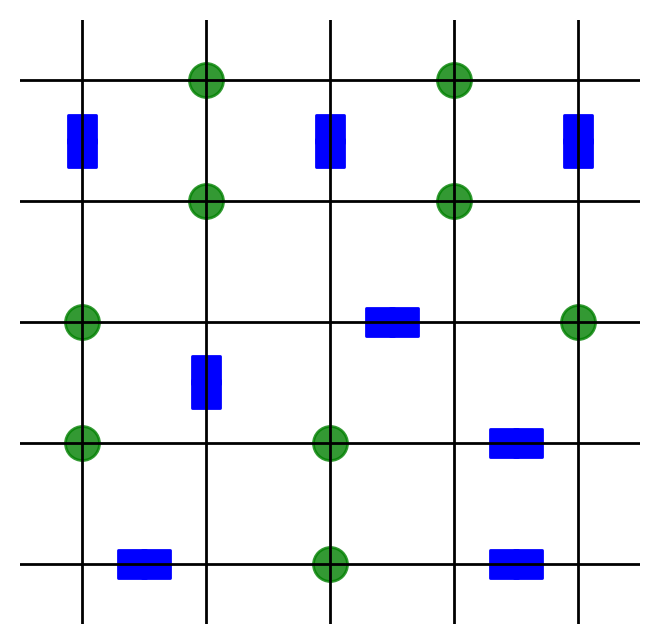

In [10]:

xmin = -2
xmax = 2

ymin = -2
ymax = 2

f0 = 5
omega0 = 2
gamma = 0.1

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,4), dpi = 200)

axis.tick_params(axis='y', which='both', bottom=False, top=False, labelbottom=False, labeltop=0)
axis.set_yticks([])
axis.set_yticklabels([])
axis.tick_params(axis='x', which='both', bottom=0, top=False, labelbottom=0)

axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
axis.spines['bottom'].set_visible(False)
axis.spines['left'].set_visible(False)

# axis.arrow(xmin, 0, xmax - xmin, 0, head_width=0.25, head_length=0.25, length_includes_head=True, color='k', lw=2)
# axis.arrow(0, ymin, 0, ymax - ymin, head_width=0.25, head_length=0.25, length_includes_head=True, color='k', lw=2)

axis.set_xlim(xmin, xmax)
axis.set_ylim(ymin, ymax)

L = 10
dx = 2*(xmax - xmin) / L
for x in np.arange(xmin + dx/2, xmax+0.1, dx):
    axis.axvline(x=x, ls='-', color='k', lw=1)
    axis.axhline(y=x, ls='-', color='k', lw=1)
    
N = L**2 / 2

positions = [
    [1,3], [1,5], [3,7], [5,1], [5,3], [3,9], [7,7], [7,9], [9,5]
]

for [x,y] in positions:
    axis.scatter(xmin + x*dx/2, ymin + y*dx/2, marker='o', color='red', s=150, edgecolor='green', facecolor='green', alpha=0.8)

doublons_horizontal = [
    [2,1], [8,3],[8,1], [6,5]
]

for [x,y] in doublons_horizontal:
    axis.scatter(xmin + x*dx/2 - dx/10, ymin + y*dx/2, marker='s', color='blue', s=100)
    axis.scatter(xmin + x*dx/2 + dx/10, ymin + y*dx/2, marker='s', color='blue', s=100)
    
    
doublons_vertical = [
    [1,8],[3,4],[5,8],[9,8]
]
for [x,y] in doublons_vertical:
    axis.scatter(xmin + x*dx/2, ymin + y*dx/2 - dx/10, marker='s', color='blue', s=100)
    axis.scatter(xmin + x*dx/2, ymin + y*dx/2 + dx/10, marker='s', color='blue', s=100)



### FERMIONIC

0.8000000000000003
-1.16
-0.7599999999999998
-1.56
1.6400000000000001


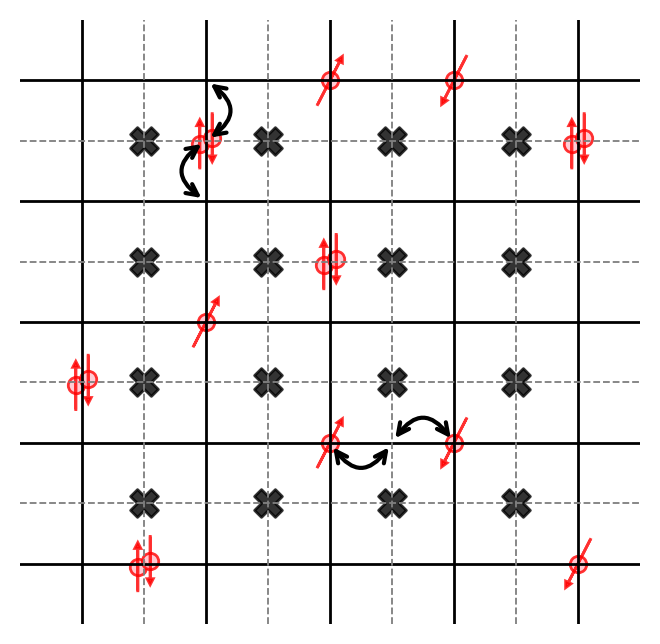

In [56]:
from scipy.special import jv
xmin = -2
xmax = 2

ymin = -2
ymax = 2

f0 = 5
omega0 = 2
gamma = 0.1

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,4), dpi = 200)

axis.tick_params(axis='y', which='both', bottom=False, top=False, labelbottom=False, labeltop=0)
axis.set_yticks([])
axis.set_yticklabels([])
axis.tick_params(axis='x', which='both', bottom=0, top=False, labelbottom=0)

axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
axis.spines['bottom'].set_visible(False)
axis.spines['left'].set_visible(False)

# axis.arrow(xmin, 0, xmax - xmin, 0, head_width=0.25, head_length=0.25, length_includes_head=True, color='k', lw=2)
# axis.arrow(0, ymin, 0, ymax - ymin, head_width=0.25, head_length=0.25, length_includes_head=True, color='k', lw=2)

axis.set_xlim(xmin, xmax)
axis.set_ylim(ymin, ymax)

L = 10
dx = 2*(xmax - xmin) / L
for x in np.arange(xmin + dx/2, xmax+0.1, dx):
    axis.axvline(x=x, ls='-', color='k', lw=1)
    axis.axhline(y=x, ls='-', color='k', lw=1)
    
for x in np.arange(xmin + dx, xmax+0., dx):
    axis.axvline(x=x, ls='--', color='gray', lw=0.66)
    axis.axhline(y=x, ls='--', color='gray', lw=0.66)

N = L**2 / 2

positions = [
    [3,5],[5,3], [5,9]
]
for [x,y] in positions:
    axis.scatter(xmin + x*dx/2, ymin + y*dx/2, marker='o', color='red', s=35, edgecolor='red', facecolor='pink', alpha=0.8)
    axis.arrow(xmin + x*dx/2-dx/10, ymin + y*dx/2 - dx/5, dx/5, dx/2.5, color='red', alpha=0.8, head_width=0.04, head_length=0.04, length_includes_head=True, lw=1)

positions = [
    [9,1], [7,9], [7, 3]
]
for [x,y] in positions:
    axis.scatter(xmin + x*dx/2, ymin + y*dx/2, marker='o', color='red', s=35, edgecolor='red', facecolor='pink', alpha=0.8)
    axis.arrow(xmin + x*dx/2+dx/10, ymin + y*dx/2 + dx/5, -dx/5, -dx/2.5, color='red', alpha=0.8, head_width=0.04, head_length=0.04, length_includes_head=True, lw=1)


positions = [
    [2,1],[3,8], [1,4], [9,8], [5,6] 
]
for [x2,y2] in positions:
    print(xmin + x*dx/2)
    x = x2 - 1 / 10
    y = y2 - 1 / 20
    axis.scatter(xmin + x*dx/2, ymin + y*dx/2, marker='o', color='red', s=35, edgecolor='red', facecolor='pink', alpha=0.8)
    axis.arrow(xmin + x*dx/2, ymin + y*dx/2 - dx/5, 0, dx/2.5, color='red', alpha=0.8, head_width=0.04, head_length=0.04, length_includes_head=True, lw=1)
    
    x = x2 + 1 / 10
    y = y2 + 1 / 20
    axis.scatter(xmin + x*dx/2, ymin + y*dx/2, marker='o', color='red', s=35, edgecolor='red', facecolor='pink', alpha=0.8)
    axis.arrow(xmin + x*dx/2, ymin + y*dx/2 + dx/5, 0, -dx/2.5, color='red', alpha=0.8, head_width=0.04, head_length=0.04, length_includes_head=True, lw=1)

for x in np.arange(2, L, 2):
    for y in np.arange(2, L, 2):
        axis.scatter(xmin + x*dx/2, ymin + y*dx/2, marker='X', color='k', s=100, edgecolor='k', facecolor='k', alpha=0.8)
    
# Helper: convert grid indices to physical coordinates
def grid_to_coord(x_grid, y_grid):
    return xmin + x_grid * dx / 2, ymin + y_grid * dx / 2

# Add curved double-headed arrows from particles to neighboring empty sites
[x, y] = [6, 3]
x_coord, y_coord = grid_to_coord(x, y)
nx, ny = x+1, y
nx_coord, ny_coord = grid_to_coord(nx, ny)
add_curved_double_arrow_simple(axis, x_coord, y_coord, nx_coord, ny_coord, color='k', lw=1.5, rad=-0.75)
nx, ny = x-1, y
nx_coord, ny_coord = grid_to_coord(nx, ny)
add_curved_double_arrow_simple(axis, x_coord, y_coord, nx_coord, ny_coord, color='k', lw=1.5, rad=-0.75)

[x, y] = [3, 8]
x_coord, y_coord = grid_to_coord(x, y)
nx, ny = x, y+1
nx_coord, ny_coord = grid_to_coord(nx, ny)
add_curved_double_arrow_simple(axis, x_coord, y_coord, nx_coord, ny_coord, color='k', lw=1.5, rad=0.75)
nx, ny = x, y-1
nx_coord, ny_coord = grid_to_coord(nx, ny)
add_curved_double_arrow_simple(axis, x_coord, y_coord, nx_coord, ny_coord, color='k', lw=1.5, rad=0.75)

# plt.savefig("figures/P10.1.pdf", bbox_inches = 'tight', pad_inches=0.02)

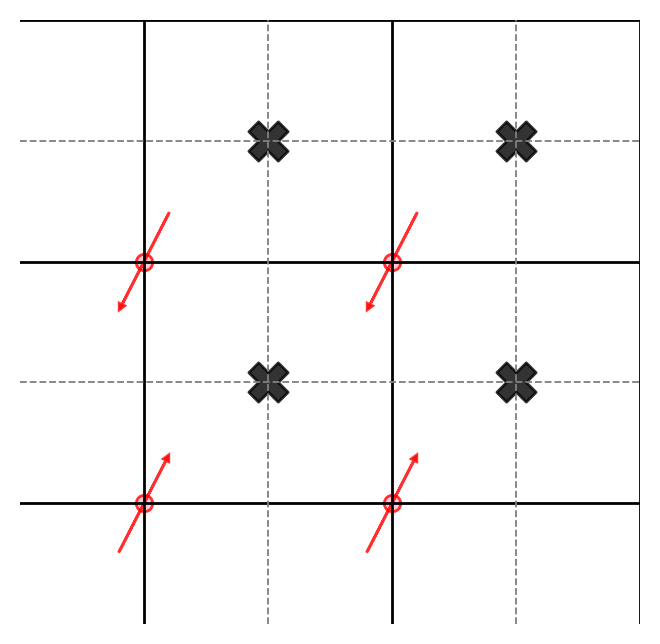

In [54]:
from scipy.special import jv
xmin = -2
xmax = 2

ymin = -2
ymax = 2

f0 = 5
omega0 = 2
gamma = 0.1

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,4), dpi = 200)

axis.tick_params(axis='y', which='both', bottom=False, top=False, labelbottom=False, labeltop=0)
axis.set_yticks([])
axis.set_yticklabels([])
axis.tick_params(axis='x', which='both', bottom=0, top=False, labelbottom=0)

axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
axis.spines['bottom'].set_visible(False)
axis.spines['left'].set_visible(False)

# axis.arrow(xmin, 0, xmax - xmin, 0, head_width=0.25, head_length=0.25, length_includes_head=True, color='k', lw=2)
# axis.arrow(0, ymin, 0, ymax - ymin, head_width=0.25, head_length=0.25, length_includes_head=True, color='k', lw=2)

axis.set_xlim(xmin, xmax)
axis.set_ylim(ymin, ymax)

L = 5
dx = 2*(xmax - xmin) / L
for x in np.arange(xmin + dx/2, xmax+0.1, dx):
    axis.axvline(x=x, ls='-', color='k', lw=1)
    axis.axhline(y=x, ls='-', color='k', lw=1)
    
for x in np.arange(xmin + dx, xmax+0., dx):
    axis.axvline(x=x, ls='--', color='gray', lw=0.66)
    axis.axhline(y=x, ls='--', color='gray', lw=0.66)

N = L**2 / 2

positions = [
    [1,1],[3,1]
]
for [x,y] in positions:
    axis.scatter(xmin + x*dx/2, ymin + y*dx/2, marker='o', color='red', s=35, edgecolor='red', facecolor='pink', alpha=0.8)
    axis.arrow(xmin + x*dx/2-dx/10, ymin + y*dx/2 - dx/5, dx/5, dx/2.5, color='red', alpha=0.8, head_width=0.04, head_length=0.04, length_includes_head=True, lw=1)

positions = [
    [1,3], [3,3]
]
for [x,y] in positions:
    axis.scatter(xmin + x*dx/2, ymin + y*dx/2, marker='o', color='red', s=35, edgecolor='red', facecolor='pink', alpha=0.8)
    axis.arrow(xmin + x*dx/2+dx/10, ymin + y*dx/2 + dx/5, -dx/5, -dx/2.5, color='red', alpha=0.8, head_width=0.04, head_length=0.04, length_includes_head=True, lw=1)

positions = [
    [2,2], [2,4], [4,2], [4,4]
]
for [x,y] in positions:
    axis.scatter(xmin + x*dx/2, ymin + y*dx/2, marker='X', color='k', s=200, edgecolor='k', facecolor='k', alpha=0.8)
    # axis.arrow(xmin + x*dx/2+dx/10, ymin + y*dx/2 + dx/5, -dx/5, -dx/2.5, color='red', alpha=0.8, head_width=0.04, head_length=0.04, length_includes_head=True, lw=1)

# positions = [
#     [2,1],[3,8], [1,4], [9,8], [5,6] 
# ]
# for [x2,y2] in positions:
#     print(xmin + x*dx/2)
#     x = x2 - 1 / 10
#     y = y2 - 1 / 20
#     axis.scatter(xmin + x*dx/2, ymin + y*dx/2, marker='o', color='red', s=35, edgecolor='red', facecolor='pink', alpha=0.8)
#     axis.arrow(xmin + x*dx/2, ymin + y*dx/2 - dx/5, 0, dx/2.5, color='red', alpha=0.8, head_width=0.04, head_length=0.04, length_includes_head=True, lw=1)
    
#     x = x2 + 1 / 10
#     y = y2 + 1 / 20
#     axis.scatter(xmin + x*dx/2, ymin + y*dx/2, marker='o', color='red', s=35, edgecolor='red', facecolor='pink', alpha=0.8)
#     axis.arrow(xmin + x*dx/2, ymin + y*dx/2 + dx/5, 0, -dx/2.5, color='red', alpha=0.8, head_width=0.04, head_length=0.04, length_includes_head=True, lw=1)

# Helper: convert grid indices to physical coordinates
def grid_to_coord(x_grid, y_grid):
    return xmin + x_grid * dx / 2, ymin + y_grid * dx / 2

# # Add curved double-headed arrows from particles to neighboring empty sites
# [x, y] = [6, 3]
# x_coord, y_coord = grid_to_coord(x, y)
# nx, ny = x+1, y
# nx_coord, ny_coord = grid_to_coord(nx, ny)
# add_curved_double_arrow_simple(axis, x_coord, y_coord, nx_coord, ny_coord, color='k', lw=1.5, rad=-0.75)
# nx, ny = x-1, y
# nx_coord, ny_coord = grid_to_coord(nx, ny)
# add_curved_double_arrow_simple(axis, x_coord, y_coord, nx_coord, ny_coord, color='k', lw=1.5, rad=-0.75)

# [x, y] = [3, 8]
# x_coord, y_coord = grid_to_coord(x, y)
# nx, ny = x, y+1
# nx_coord, ny_coord = grid_to_coord(nx, ny)
# add_curved_double_arrow_simple(axis, x_coord, y_coord, nx_coord, ny_coord, color='k', lw=1.5, rad=0.75)
# nx, ny = x, y-1
# nx_coord, ny_coord = grid_to_coord(nx, ny)
# add_curved_double_arrow_simple(axis, x_coord, y_coord, nx_coord, ny_coord, color='k', lw=1.5, rad=0.75)

# plt.savefig("figures/P10.1.pdf", bbox_inches = 'tight', pad_inches=0.02)

3.2082593202564595
5.588200109794961
8.101474232666796


Text(16.878759594743862, 1.17, '$J$')

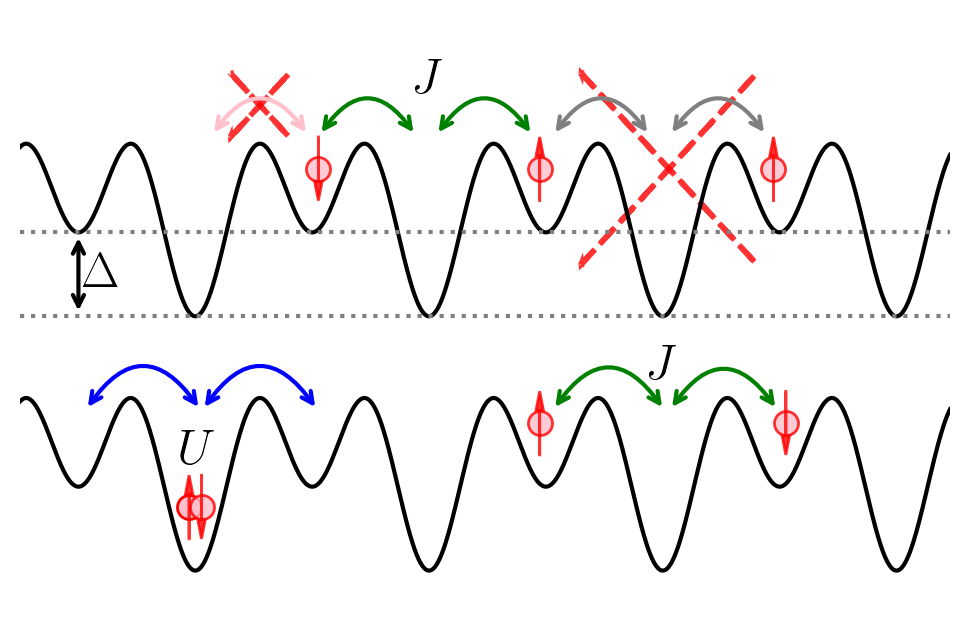

In [7]:

xmin = 0
xmax = 25

ymin = -0.75
ymax = 4

f0 = 5
omega0 = 2
gamma = 0.1

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(6,4), dpi = 200)

axis.tick_params(axis='y', which='both', bottom=False, top=False, labelbottom=False, labeltop=0)
axis.set_yticks([])
axis.set_yticklabels([])
axis.tick_params(axis='x', which='both', bottom=0, top=False, labelbottom=0)

axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
axis.spines['bottom'].set_visible(False)
axis.spines['left'].set_visible(False)

# axis.arrow(xmin, 0, xmax - xmin, 0, head_width=0.25, head_length=0.25, length_includes_head=True, color='k', lw=2)
# axis.arrow(0, ymin, 0, ymax - ymin, head_width=0.25, head_length=0.25, length_includes_head=True, color='k', lw=2)

axis.set_xlim(xmin, xmax)
axis.set_ylim(ymin, ymax)

x = np.linspace(0, 25, 1000)
# axis.plot(x, np.sin(x))

def superpotential(x):
    return np.sin(x+np.pi/2)**2 + 0.33*np.sin(x)
axis.plot(x, superpotential(x), color='k')

axis.plot(x, 2+superpotential(x), color='k')

# axis.plot(x, 4+superpotential(x), color='k')

x2 = np.pi*3/2
y2 = superpotential(x2)
x = x2 - 1 / 6
y = y2 + 0.5
axis.scatter(x, y, marker='o', color='red', s=75, edgecolor='red', facecolor='pink')
axis.arrow(x, y - 0.25, 0, 0.5, color='red', alpha=0.8, head_width=0.2, head_length=0.15, length_includes_head=True, lw=1)

x = x2 + 1 / 6
y = y2 + 0.5
axis.scatter(x, y, marker='o', color='red', s=75, edgecolor='red', facecolor='pink', alpha=0.8)
axis.arrow(x, y + 0.25, 0, -0.5, color='red', alpha=0.8, head_width=0.2, head_length=0.15, length_includes_head=True, lw=1)

add_curved_double_arrow_simple(axis, x, y+0.75, x + np.pi, y+0.75, color='blue', lw=1.5, rad=-0.75)
add_curved_double_arrow_simple(axis, x, y+0.75, x - np.pi, y+0.75, color='blue', lw=1.5, rad=0.75)
add_curved_double_arrow_simple(axis, x + 0.0 + 3*np.pi, y+0.75, x + 4*np.pi - 0.1, y+0.75, color='green', lw=1.5, rad=-0.75)
add_curved_double_arrow_simple(axis, x + 0.0 + 4*np.pi, y+0.75, x + 5*np.pi - 0.2, y+0.75, color='green', lw=1.5, rad=-0.75)

x2 = np.pi*1/2
y2 = 2+superpotential(x2)
x = x2 - 1 / 6
y = y2 + 0.5
# axis.scatter(x, y, marker='o', color='red', s=75, edgecolor='red', facecolor='pink', alpha=0.8)
# axis.arrow(x, y - 0.25, 0, 0.5, color='red', alpha=0.8, head_width=0.2, head_length=0.15, length_includes_head=True, lw=1)

x2 = np.pi*5/2
y2 = 2+superpotential(x2)
x = x2 + 1 / 6
y = y2 + 0.5
axis.scatter(x, y, marker='o', color='red', s=75, edgecolor='red', facecolor='pink', alpha=0.8)
axis.arrow(x, y + 0.25, 0, -0.5, color='red', alpha=0.8, head_width=0.2, head_length=0.15, length_includes_head=True, lw=1)

# add_curved_double_arrow_simple(axis, x - 2*np.pi, y+0.25, x - np.pi - 0.5, y+0.25, color='blue', lw=1.5, rad=-0.75)
add_curved_double_arrow_simple(axis, x - 0.25, y + 0.25, x - np.pi + 0.25, y+0.25, color='pink', lw=1.5, rad=0.75)
add_curved_double_arrow_simple(axis, x + 0.0, y+0.25, x + np.pi - 0.5, y+0.25, color='green', lw=1.5, rad=-0.75)
add_curved_double_arrow_simple(axis, x + 0.0 + np.pi, y+0.25, x + 2*np.pi - 0.5, y+0.25, color='green', lw=1.5, rad=-0.75)
add_curved_double_arrow_simple(axis, x + 0.0 + 2*np.pi, y+0.25, x + 3*np.pi - 0.5, y+0.25, color='gray', lw=1.5, rad=-0.75)
add_curved_double_arrow_simple(axis, x + 0.0 + 3*np.pi, y+0.25, x + 4*np.pi - 0.5, y+0.25, color='gray', lw=1.5, rad=-0.75)

x2 = np.pi*9/2
y2 = 2+superpotential(x2)
print(xmin + x*dx/2)
x = x2 - 1 / 6
y = y2 + 0.5
axis.scatter(x, y, marker='o', color='red', s=75, edgecolor='red', facecolor='pink', alpha=0.8)
axis.arrow(x, y - 0.25, 0, 0.5, color='red', alpha=0.8, head_width=0.2, head_length=0.15, length_includes_head=True, lw=1)

x2 = np.pi*13/2
y2 = 2+superpotential(x2)
print(xmin + x*dx/2)
x = x2 - 1 / 6
y = y2 + 0.5
axis.scatter(x, y, marker='o', color='red', s=75, edgecolor='red', facecolor='pink', alpha=0.8)
axis.arrow(x, y - 0.25, 0, 0.5, color='red', alpha=0.8, head_width=0.2, head_length=0.15, length_includes_head=True, lw=1)

x2 = np.pi*9/2
y2 = superpotential(x2)
print(xmin + x*dx/2)
x = x2 - 1 / 6
y = y2 + 0.5
axis.scatter(x, y, marker='o', color='red', s=75, edgecolor='red', facecolor='pink', alpha=0.8)
axis.arrow(x, y - 0.25, 0, 0.5, color='red', alpha=0.8, head_width=0.2, head_length=0.15, length_includes_head=True, lw=1)

x2 = np.pi*13/2
y2 = superpotential(x2)
x = x2 + 1 / 6
y = y2 + 0.5
axis.scatter(x, y, marker='o', color='red', s=75, edgecolor='red', facecolor='pink', alpha=0.8)
axis.arrow(x, y + 0.25, 0, -0.5, color='red', alpha=0.8, head_width=0.2, head_length=0.15, length_includes_head=True, lw=1)

axis.arrow(x-0.25*np.pi, 2+y-0.75, -1.5*np.pi, 1.5, color='red', alpha=0.8, lw=2, ls='--')
axis.arrow(x-0.25*np.pi, 2+y+0.75, -1.5*np.pi, -1.5, color='red', alpha=0.8, lw=2, ls='--')

x2 = 5*np.pi/2
y2 = superpotential(x2)
x = x2 + 1 / 6
y = y2 + 1.
axis.arrow(x-0.25*np.pi, 2+y-0.25, -0.5*np.pi, 0.5, color='red', alpha=0.8, lw=2, ls='--')
axis.arrow(x-0.25*np.pi, 2+y+0.25, -0.5*np.pi, -0.5, color='red', alpha=0.8, lw=2, ls='--')
add_curved_double_arrow_simple(axis, np.pi/2, 2+superpotential(np.pi/2), np.pi/2, 2+superpotential(3*np.pi/2), color='k', lw=1.5, rad=-0.0)


axis.axhline(y=2+superpotential(np.pi/2), ls=':', color='gray')
axis.axhline(y=2+superpotential(3*np.pi/2), ls=':', color='gray')
axis.text(np.pi/2+0.1, 2 + (superpotential(np.pi/2)+superpotential(3*np.pi/2))/2 - 0.1, r'$\Delta$', color='k', fontsize=18)

axis.text(3*np.pi/2-0.4, (superpotential(np.pi/2)+superpotential(3*np.pi/2))/2 + 0.5, r'$U$', color='k', fontsize=18)
axis.text(7*np.pi/2-0.4, 2 + superpotential(7*np.pi/2) + 1.75, r'$J$', color='k', fontsize=18)
# axis.text(11*np.pi/2-0.4, 2 + superpotential(7*np.pi/2) + 1.75, r'$J$', color='k', fontsize=18)
axis.text(11*np.pi/2-0.4, superpotential(7*np.pi/2) + 1.5, r'$J$', color='k', fontsize=18)

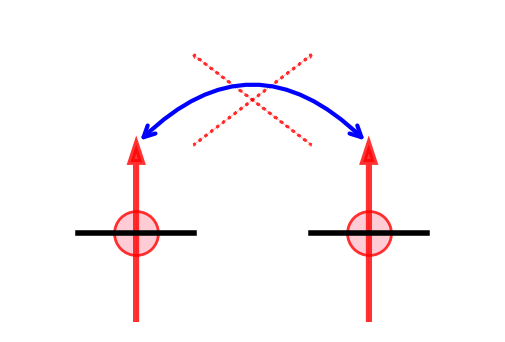

In [9]:

xmin = 0.
xmax = 2

ymin = 0.25
ymax = 1.1

f0 = 5
omega0 = 2
gamma = 0.1

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(3,2), dpi = 200)

axis.tick_params(axis='y', which='both', bottom=False, top=False, labelbottom=False, labeltop=0)
axis.set_yticks([])
axis.set_yticklabels([])
axis.tick_params(axis='x', which='both', bottom=0, top=False, labelbottom=0)

axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
axis.spines['bottom'].set_visible(False)
axis.spines['left'].set_visible(False)

# axis.arrow(xmin, 0, xmax - xmin, 0, head_width=0.25, head_length=0.25, length_includes_head=True, color='k', lw=2)
# axis.arrow(0, ymin, 0, ymax - ymin, head_width=0.25, head_length=0.25, length_includes_head=True, color='k', lw=2)

axis.set_xlim(xmin, xmax)
axis.set_ylim(ymin, ymax)

# lattice
axis.plot([0.25,0.75], [0.5, 0.5], color='k', lw=2)
axis.plot([1.25,1.75], [0.5, 0.5], color='k', lw=2)
axis.scatter(0.5, 0.5, marker='o', color='red', s=250, edgecolor='red', facecolor='pink', alpha=0.8)
axis.scatter(1.5, 0.5, marker='o', color='red', s=250, edgecolor='red', facecolor='pink', alpha=0.8)
axis.arrow(0.5, 0.25, 0, 0.5, color='red', alpha=0.8, head_width=0.05, head_length=0.05, length_includes_head=True, lw=2)
axis.arrow(1.5, 0.25, 0, 0.5, color='red', alpha=0.8, head_width=0.05, head_length=0.05, length_includes_head=True, lw=2)

add_curved_double_arrow_simple(axis, 0.5, 0.75, 1.5, 0.75, color='blue', lw=1.5, rad=-0.5)

axis.arrow(0.75, 0.75, 0.5, 0.25, color='red', alpha=0.8, lw=1, ls=':')
axis.arrow(1.25, 0.75, -0.5, 0.25, color='red', alpha=0.8, lw=1, ls=':')

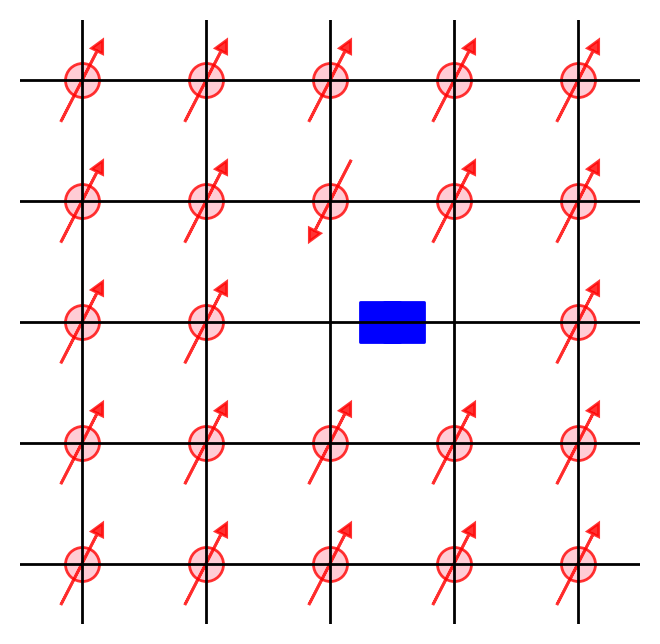

In [5]:

xmin = -1
xmax = 1

ymin = -1
ymax = 1

f0 = 5
omega0 = 2
gamma = 0.1

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,4), dpi = 200)

axis.tick_params(axis='y', which='both', bottom=False, top=False, labelbottom=False, labeltop=0)
axis.set_yticks([])
axis.set_yticklabels([])
axis.tick_params(axis='x', which='both', bottom=0, top=False, labelbottom=0)

axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
axis.spines['bottom'].set_visible(False)
axis.spines['left'].set_visible(False)

# axis.arrow(xmin, 0, xmax - xmin, 0, head_width=0.25, head_length=0.25, length_includes_head=True, color='k', lw=2)
# axis.arrow(0, ymin, 0, ymax - ymin, head_width=0.25, head_length=0.25, length_includes_head=True, color='k', lw=2)

axis.set_xlim(xmin, xmax)
axis.set_ylim(ymin, ymax)

L = 10
dx = 2*(xmax - xmin) / L
for x in np.arange(xmin + dx/2, xmax+0.1, dx):
    axis.axvline(x=x, ls='-', color='k', lw=1)
    axis.axhline(y=x, ls='-', color='k', lw=1)
    
N = L**2 / 2

positions = [
    [1,1]
]

for x in range(1,L+1, 2):
    for y in range(1,L+1, 2):
        if x == 7 and y == 5: continue
        if x == 5 and y == 7: continue
        if x == 5 and y == 5: continue
        axis.scatter(xmin + x*dx/2, ymin + y*dx/2, marker='o', color='red', s=150, edgecolor='red', facecolor='pink', alpha=0.8)
        axis.arrow(xmin + x*dx/2-dx/6, ymin + y*dx/2 - dx/3, dx/3, dx/1.5, color='red', alpha=0.8, head_width=0.04, head_length=0.04, length_includes_head=True, lw=1)

positions = [
    [L//2,L//2+2]
]

for [x,y] in positions:
    axis.scatter(xmin + x*dx/2, ymin + y*dx/2, marker='o', color='red', s=150, edgecolor='red', facecolor='pink', alpha=0.8)
    axis.arrow(xmin + x*dx/2+dx/6, ymin + y*dx/2 + dx/3, -dx/3, -dx/1.5, color='red', alpha=0.8, head_width=0.04, head_length=0.04, length_includes_head=True, lw=1)


doublons_horizontal = [
    [6,5]
]

for [x,y] in doublons_horizontal:
    axis.scatter(xmin + x*dx/2 - dx/10, ymin + y*dx/2, marker='s', color='blue', s=200)
    axis.scatter(xmin + x*dx/2 + dx/10, ymin + y*dx/2, marker='s', color='blue', s=200)
    
    
# doublons_vertical = [
#     [1,2]
# ]
# for [x,y] in doublons_vertical:
#     axis.scatter(xmin + x*dx/2, ymin + y*dx/2 - dx/10, marker='s', color='blue', s=200)
#     axis.scatter(xmin + x*dx/2, ymin + y*dx/2 + dx/10, marker='s', color='blue', s=200)



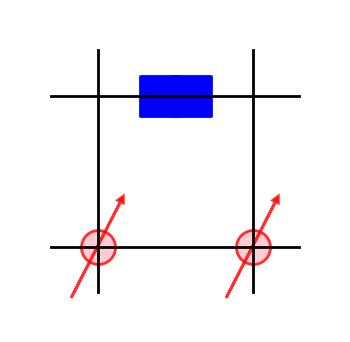

In [27]:

xmin = -1
xmax = 1

ymin = -1
ymax = 1

f0 = 5
omega0 = 2
gamma = 0.1

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(2,2), dpi = 200)

axis.tick_params(axis='y', which='both', bottom=False, top=False, labelbottom=False, labeltop=0)
axis.set_yticks([])
axis.set_yticklabels([])
axis.tick_params(axis='x', which='both', bottom=0, top=False, labelbottom=0)

axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
axis.spines['bottom'].set_visible(False)
axis.spines['left'].set_visible(False)

# axis.arrow(xmin, 0, xmax - xmin, 0, head_width=0.25, head_length=0.25, length_includes_head=True, color='k', lw=2)
# axis.arrow(0, ymin, 0, ymax - ymin, head_width=0.25, head_length=0.25, length_includes_head=True, color='k', lw=2)

axis.set_xlim(xmin, xmax)
axis.set_ylim(ymin, ymax)

L = 4
dx = 2*(xmax - xmin) / L
for x in np.arange(xmin + dx/2, xmax+0.1, dx):
    axis.axvline(x=x, ls='-', color='k', lw=1, ymin=0.1, ymax=0.9)
    axis.axhline(y=x, ls='-', color='k', lw=1, xmin=0.1, xmax=0.9)
    
N = L**2 / 2

positions = [
    [1,1]
]

for x in range(1,L+1, 2):
    for y in range(1,L+1, 2):
        if x == 1 and y == 3: continue
        if x == 3 and y == 3: continue
        axis.scatter(xmin + x*dx/2, ymin + y*dx/2, marker='o', color='red', s=150, edgecolor='red', facecolor='pink', alpha=0.8)
        axis.arrow(xmin + x*dx/2-dx/6, ymin + y*dx/2 - dx/3, dx/3, dx/1.5, color='red', alpha=0.8, head_width=0.04, head_length=0.04, length_includes_head=True, lw=1)

# positions = [
#     [L//2,L//2+2]
# ]

# for [x,y] in positions:
#     axis.scatter(xmin + x*dx/2, ymin + y*dx/2, marker='o', color='red', s=150, edgecolor='red', facecolor='pink', alpha=0.8)
#     axis.arrow(xmin + x*dx/2+dx/6, ymin + y*dx/2 + dx/3, -dx/3, -dx/1.5, color='red', alpha=0.8, head_width=0.04, head_length=0.04, length_includes_head=True, lw=1)


doublons_horizontal = [
    [2,3]
]

for [x,y] in doublons_horizontal:
    axis.scatter(xmin + x*dx/2 - dx/10, ymin + y*dx/2, marker='s', color='blue', s=200)
    axis.scatter(xmin + x*dx/2 + dx/10, ymin + y*dx/2, marker='s', color='blue', s=200)
    
    
# doublons_vertical = [
#     [3,2]
# ]
# for [x,y] in doublons_vertical:
#     axis.scatter(xmin + x*dx/2, ymin + y*dx/2 - dx/10, marker='s', color='blue', s=200)
#     axis.scatter(xmin + x*dx/2, ymin + y*dx/2 + dx/10, marker='s', color='blue', s=200)



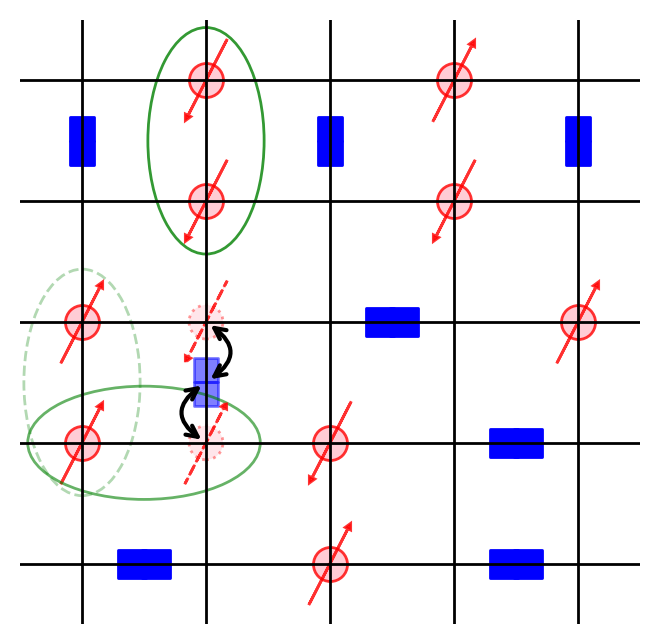

In [3]:

xmin = -2
xmax = 2

ymin = -2
ymax = 2

f0 = 5
omega0 = 2
gamma = 0.1

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,4), dpi = 200)

axis.tick_params(axis='y', which='both', bottom=False, top=False, labelbottom=False, labeltop=0)
axis.set_yticks([])
axis.set_yticklabels([])
axis.tick_params(axis='x', which='both', bottom=0, top=False, labelbottom=0)

axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
axis.spines['bottom'].set_visible(False)
axis.spines['left'].set_visible(False)

# axis.arrow(xmin, 0, xmax - xmin, 0, head_width=0.25, head_length=0.25, length_includes_head=True, color='k', lw=2)
# axis.arrow(0, ymin, 0, ymax - ymin, head_width=0.25, head_length=0.25, length_includes_head=True, color='k', lw=2)

axis.set_xlim(xmin, xmax)
axis.set_ylim(ymin, ymax)

L = 10
dx = 2*(xmax - xmin) / L
for x in np.arange(xmin + dx/2, xmax+0.1, dx):
    axis.axvline(x=x, ls='-', color='k', lw=1)
    axis.axhline(y=x, ls='-', color='k', lw=1)
    
N = L**2 / 2

positions = [
    [1,3], [5,1], [7,9], [9,5], [1,5]
]

for [x,y] in positions:
    axis.scatter(xmin + x*dx/2, ymin + y*dx/2, marker='o', color='red', s=150, edgecolor='red', facecolor='pink', alpha=0.8)
    axis.arrow(xmin + x*dx/2-dx/6, ymin + y*dx/2 - dx/3, dx/3, dx/1.5, color='red', alpha=0.8, head_width=0.04, head_length=0.04, length_includes_head=True, lw=1)

positions = [
    [3,7], [3,9], [7,7], [5,3]
]

for [x,y] in positions:
    axis.scatter(xmin + x*dx/2, ymin + y*dx/2, marker='o', color='red', s=150, edgecolor='red', facecolor='pink', alpha=0.8)
    axis.arrow(xmin + x*dx/2+dx/6, ymin + y*dx/2 + dx/3, -dx/3, -dx/1.5, color='red', alpha=0.8, head_width=0.04, head_length=0.04, length_includes_head=True, lw=1)


doublons_horizontal = [
    [2,1], [8,3],[8,1], [6,5]#, [2,5]#, [4,3]
]

for [x,y] in doublons_horizontal:
    axis.scatter(xmin + x*dx/2 - dx/10, ymin + y*dx/2, marker='s', color='blue', s=100)
    axis.scatter(xmin + x*dx/2 + dx/10, ymin + y*dx/2, marker='s', color='blue', s=100)
    
    
doublons_vertical = [
    [1,8],[5,8],[9,8]
]
for [x,y] in doublons_vertical:
    axis.scatter(xmin + x*dx/2, ymin + y*dx/2 - dx/10, marker='s', color='blue', s=75)
    axis.scatter(xmin + x*dx/2, ymin + y*dx/2 + dx/10, marker='s', color='blue', s=75)

x,y = 3, 4
axis.scatter(xmin + x*dx/2, ymin + y*dx/2 - dx/10, marker='s', color='blue', s=75, alpha = 0.5)
axis.scatter(xmin + x*dx/2, ymin + y*dx/2 + dx/10, marker='s', color='blue', s=75, alpha = 0.5)

from matplotlib.patches import Ellipse

# Define ellipse parameters
for [center_x, center_y] in [[3, 8]]:
    width = 0.75       # total width (along x-axis)
    height = 1.5      # total height (along y-axis)
    angle = 00        # rotation angle in degrees (optional)

    # Create ellipse
    ellipse = Ellipse(
        (xmin + center_x*dx/2, ymin + center_y*dx/2),
        width=width,
        height=height,
        angle=angle,
        edgecolor='green',
        facecolor='None',
        alpha=0.8,        # transparency
        lw=1              # line width
    )

    # Add to axis
    axis.add_patch(ellipse)

# # Define ellipse parameters
for [center_x, center_y] in [[1, 4]]:
    width = 0.75       # total width (along x-axis)
    height = 1.5      # total height (along y-axis)
    angle = 00        # rotation angle in degrees (optional)

    # Create ellipse
    ellipse = Ellipse(
        (xmin + center_x*dx/2, ymin + center_y*dx/2),
        width=width,
        height=height,
        angle=angle,
        edgecolor='green',
        facecolor='None',
        alpha=0.3,        # transparency
        lw=1, ls='--'              # line width
    )

    # Add to axis
    axis.add_patch(ellipse)

for [center_x, center_y] in [[2, 3]]:
    width = 1.5       # total width (along x-axis)
    height = 0.75      # total height (along y-axis)
    angle = 00        # rotation angle in degrees (optional)

    # Create ellipse
    ellipse = Ellipse(
        (xmin + center_x*dx/2, ymin + center_y*dx/2),
        width=width,
        height=height,
        angle=angle,
        edgecolor='green',
        facecolor='None',
        alpha=0.6,        # transparency
        lw=1, ls='-'              # line width
    )

    # Add to axis
    axis.add_patch(ellipse)


x, y = 3, 5
axis.scatter(xmin + x*dx/2, ymin + y*dx/2, marker='o', color='red', s=150, edgecolor='red', facecolor='pink', alpha=0.4, ls=':')
axis.arrow(xmin + x*dx/2+dx/6, ymin + y*dx/2 + dx/3, -dx/3, -dx/1.5, color='red', alpha=0.8, head_width=0.04, head_length=0.04, length_includes_head=True, lw=1, ls='--')
add_curved_double_arrow_simple(axis, xmin + x*dx/2, ymin + y*dx/2, xmin + (x)*dx/2, ymin + (y-1)*dx/2, color='k', lw=1.5, rad=-0.75)
x, y = 3, 3
axis.scatter(xmin + x*dx/2, ymin + y*dx/2, marker='o', color='red', s=150, edgecolor='red', facecolor='pink', alpha=0.4, ls=':')
axis.arrow(xmin + x*dx/2-dx/6, ymin + y*dx/2 - dx/3, dx/3, dx/1.5, color='red', alpha=0.8, head_width=0.04, head_length=0.04, length_includes_head=True, lw=1, ls='--')
add_curved_double_arrow_simple(axis, xmin + x*dx/2, ymin + y*dx/2, xmin + (x)*dx/2, ymin + (y+1)*dx/2, color='k', lw=1.5, rad=-0.75)



## OTHERSSS

In [2]:
Lxs=[21, 31, 41, 51, 61, 71, 81, 91, 101, 111, 121, 131]
for Lx in Lxs:
    print(Lx, "   ", 3*Lx**2)

21     1323
31     2883
41     5043
51     7803
61     11163
71     15123
81     19683
91     24843
101     30603
111     36963
121     43923
131     51483
